In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, math, pickle, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 12,
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


In [2]:

DATA_DIR = '/content/drive/MyDrive/LSTGAN_Data/results'

CKPT_PATH  = os.path.join(DATA_DIR, 'best_lstgan.pt')
GRAPH_FILE = os.path.join(DATA_DIR, 'adj_mx_bay.pkl')
TRAIN_FILE = os.path.join(DATA_DIR, 'train_5min.pkl')
VAL_FILE   = os.path.join(DATA_DIR, 'val_5min.pkl')
TEST_FILE  = os.path.join(DATA_DIR, 'test_5min.pkl')


for name, path in [('Checkpoint', CKPT_PATH), ('Graph', GRAPH_FILE),
                    ('Train', TRAIN_FILE), ('Val', VAL_FILE), ('Test', TEST_FILE)]:
    exists = os.path.exists(path)
    print(f'  {name:12s}: {"✓" if exists else "✗ MISSING"} {path}')

NUM_SENSORS      = 325
STEPS_PER_HOUR   = 12
STEPS_PER_DAY    = 288

WEEKLY_WINDOW    = 2016
DAILY_WINDOW     = 288
HOURLY_WINDOW    = 12
FORECAST_HORIZON = 12
EVAL_HORIZONS    = [3, 6, 12]  # H3=15min, H6=30min, H12=60min

WEEKLY_IN_CHANNELS  = 3;  WEEKLY_OUT_CHANNELS  = 16
DAILY_IN_CHANNELS   = 3;  DAILY_OUT_CHANNELS   = 8
HOURLY_IN_CHANNELS  = 1

WEEKLY_STRIDE_1 = 14; WEEKLY_STRIDE_2 = 12
DAILY_STRIDE_1  = 4;  DAILY_STRIDE_2  = 6

SPATIAL_EMBED_DIM       = 16
GLOBAL_SPATIAL_CHANNELS = 16; GLOBAL_ATTN_HEADS = 4; GLOBAL_ATTN_LAYERS = 1
LOCAL_SPATIAL_CHANNELS  = 8;  CHEBYSHEV_K = 5;      GCN_LAYERS = 1

D_MODEL = WEEKLY_OUT_CHANNELS + DAILY_OUT_CHANNELS + GLOBAL_SPATIAL_CHANNELS + LOCAL_SPATIAL_CHANNELS  # 48
TIME_ONEHOT_DIM = 7 + STEPS_PER_DAY  # 295
DECODER_HEADS = 6; DECODER_HEAD_DIM = 8; DECODER_LAYERS = 1

BATCH_SIZE = 8

print(f'\nD_MODEL={D_MODEL}, TIME_DIM={TIME_ONEHOT_DIM}, HORIZON={FORECAST_HORIZON}')

  Checkpoint  : ✓ /content/drive/MyDrive/LSTGAN_Data/results/best_lstgan.pt
  Graph       : ✓ /content/drive/MyDrive/LSTGAN_Data/results/adj_mx_bay.pkl
  Train       : ✓ /content/drive/MyDrive/LSTGAN_Data/results/train_5min.pkl
  Val         : ✓ /content/drive/MyDrive/LSTGAN_Data/results/val_5min.pkl
  Test        : ✓ /content/drive/MyDrive/LSTGAN_Data/results/test_5min.pkl

D_MODEL=48, TIME_DIM=295, HORIZON=12


In [3]:
class TrafficDataset(Dataset):
    """Multi-scale traffic forecasting dataset at 5-min resolution."""
    def __init__(self, data_df, mode='train', mean=None, std=None):
        self.mode = mode
        self.num_sensors = data_df.shape[1]
        self.mean = data_df.values.mean() if mean is None else mean
        self.std  = data_df.values.std()  if std  is None else std
        self.speed = ((data_df.values - self.mean) / (self.std + 1e-8)).astype(np.float32)
        if hasattr(data_df.index, 'weekday'):
            self.day_of_week = data_df.index.weekday.values    # 0-6
            self.time_of_day = (data_df.index.hour * 12 + data_df.index.minute // 5).values  # 0-287
        else:
            T = len(data_df)
            self.day_of_week = np.arange(T) % 7
            self.time_of_day = np.arange(T) % STEPS_PER_DAY
        self.total_steps = len(self.speed)
        self.start_offset = WEEKLY_WINDOW
        self.valid_len = self.total_steps - self.start_offset - FORECAST_HORIZON + 1
        assert self.valid_len > 0, f'Not enough data: {self.total_steps} steps'
        print(f'[{mode}] {self.total_steps} steps, {self.valid_len} samples, {self.num_sensors} sensors')

    def __len__(self): return self.valid_len

    def _time_feats(self, idx, length):
        s = idx - length
        dow = self.day_of_week[s:idx].astype(np.float32) / 6.0
        tod = self.time_of_day[s:idx].astype(np.float32) / 287.0
        return np.stack([dow, tod], axis=-1)

    def __getitem__(self, idx):
        t = self.start_offset + idx
        N = self.num_sensors

        sp_w = self.speed[t-WEEKLY_WINDOW:t]
        tf_w = self._time_feats(t, WEEKLY_WINDOW)
        X_w = np.stack([sp_w, np.tile(tf_w[:,0:1],(1,N)), np.tile(tf_w[:,1:2],(1,N))], axis=-1)

        sp_d = self.speed[t-DAILY_WINDOW:t]
        tf_d = self._time_feats(t, DAILY_WINDOW)
        X_d = np.stack([sp_d, np.tile(tf_d[:,0:1],(1,N)), np.tile(tf_d[:,1:2],(1,N))], axis=-1)

        X_h = self.speed[t-HOURLY_WINDOW:t][:,:,np.newaxis]

        t_info = np.array([self.day_of_week[t], self.time_of_day[t]], dtype=np.int64)

        Y = self.speed[t:t+FORECAST_HORIZON][:,:,np.newaxis]
        return (torch.from_numpy(X_w), torch.from_numpy(X_d), torch.from_numpy(X_h),
                torch.from_numpy(t_info), torch.from_numpy(Y))


def load_adjacency_matrix(path=GRAPH_FILE):
    with open(path, 'rb') as f:
        adj = pickle.load(f, encoding='latin1')
    if isinstance(adj, (tuple, list)):
        adj = adj[2] if len(adj) >= 3 else adj[-1]
    return adj.astype(np.float32) if isinstance(adj, np.ndarray) else adj


def get_edge_info(adj_mx):
    rows, cols = np.nonzero(adj_mx)
    return torch.LongTensor(np.stack([rows, cols])), torch.FloatTensor(adj_mx[rows, cols])

print('Dataset module ready.')

Dataset module ready.


In [4]:
class TemporalEncoder(nn.Module):
    def __init__(self, in_ch, out_ch, s1, s2):
        super().__init__()
        mid = max((in_ch + out_ch)//2, 8)
        self.c1a = nn.Conv1d(in_ch, mid, 3, padding=1)
        self.c1b = nn.Conv1d(mid, mid, s1, stride=s1) if s1>1 else nn.Identity()
        self.bn1 = nn.BatchNorm1d(mid)
        self.c2a = nn.Conv1d(mid, out_ch, 3, padding=1)
        self.c2b = nn.Conv1d(out_ch, out_ch, s2, stride=s2) if s2>1 else nn.Identity()
        self.bn2 = nn.BatchNorm1d(out_ch)
    def forward(self, x):
        B,T,N,C = x.shape
        x = x.permute(0,2,3,1).reshape(B*N, C, T)
        x = F.relu(self.bn1(self.c1b(F.relu(self.c1a(x)))))
        x = self.bn2(self.c2b(F.relu(self.c2a(x))))
        _,Co,To = x.shape
        return x.reshape(B,N,Co,To).permute(0,3,1,2)

class SpatialEmbedding(nn.Module):
    def __init__(self, in_ch=HOURLY_IN_CHANNELS, out_ch=SPATIAL_EMBED_DIM):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, 1)
        self.bn = nn.BatchNorm1d(out_ch)
    def forward(self, x):
        B,T,N,C = x.shape
        x = x.reshape(B*T, N, C).permute(0,2,1)
        x = self.bn(self.conv(x))
        return x.permute(0,2,1).reshape(B,T,N,-1)

class GlobalSpatialEncoder(nn.Module):
    def __init__(self, d=SPATIAL_EMBED_DIM, heads=GLOBAL_ATTN_HEADS, nl=GLOBAL_ATTN_LAYERS, out_ch=GLOBAL_SPATIAL_CHANNELS):
        super().__init__()
        self.layers = nn.ModuleList()
        for _ in range(nl):
            self.layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.1),
                'n1': nn.LayerNorm(d), 'n2': nn.LayerNorm(d),
                'ffn': nn.Sequential(nn.Linear(d,d*4), nn.GELU(), nn.Dropout(0.1), nn.Linear(d*4,d))}))
        self.proj = nn.Linear(d, out_ch) if d != out_ch else nn.Identity()
    def forward(self, x):
        B,T,N,C = x.shape
        x = x.reshape(B*T, N, C)
        for l in self.layers:
            a,_ = l['attn'](x,x,x); x = l['n1'](x+a); x = l['n2'](x+l['ffn'](x))
        return self.proj(x).reshape(B,T,N,-1)

class ManualChebConv(nn.Module):
    def __init__(self, in_ch, out_ch, K=CHEBYSHEV_K):
        super().__init__()
        self.K = K
        self.weights = nn.ParameterList([nn.Parameter(torch.empty(in_ch, out_ch)) for _ in range(K)])
        self.bias = nn.Parameter(torch.zeros(out_ch))
        for w in self.weights: nn.init.xavier_uniform_(w)
    def forward(self, x, L):
        Z0, Z1 = x, L @ x
        out = Z0 @ self.weights[0]
        if self.K > 1: out = out + Z1 @ self.weights[1]
        for k in range(2, self.K):
            Zk = 2*L@Z1 - Z0; out = out + Zk@self.weights[k]; Z0, Z1 = Z1, Zk
        return out + self.bias

class LocalSpatialEncoder(nn.Module):
    def __init__(self, in_ch=SPATIAL_EMBED_DIM, out_ch=LOCAL_SPATIAL_CHANNELS, K=CHEBYSHEV_K):
        super().__init__()
        self.cheb = ManualChebConv(in_ch, out_ch, K)
        self.register_buffer('L_scaled', None)

    def set_graph(self, adj_mx):
        A = adj_mx
        D_inv = np.diag(1.0/np.sqrt(np.maximum(A.sum(1), 1e-8)))
        L = np.eye(A.shape[0]) - D_inv @ A @ D_inv
        eig = np.linalg.eigvalsh(L)
        device = next(self.parameters()).device
        self.L_scaled = torch.FloatTensor(2*L/(eig[-1]+1e-8) - np.eye(A.shape[0])).to(device)

    def forward(self, x, edge_index=None, edge_weight=None):
        B,T,N,C = x.shape; L = self.L_scaled.to(x.device)
        x = x.reshape(B*T, N, C)
        out = self.cheb(x, L)
        return out.reshape(B,T,N,-1)

class TimeEncoder(nn.Module):
    def __init__(self, d=D_MODEL, tdim=TIME_ONEHOT_DIM):
        super().__init__()
        h = d*2
        self.mlp = nn.Sequential(nn.Linear(tdim,h), nn.Linear(h,h), nn.ReLU(), nn.Linear(h,d))
        self.norm = nn.LayerNorm(d)
    def forward(self, ste, time_info):
        B,T,N,d = ste.shape
        dow = F.one_hot(time_info[:,0].long(), 7).float()
        tod = F.one_hot(time_info[:,1].long(), 288).float()
        vt = self.mlp(torch.cat([dow,tod],-1))[:,None,None,:].expand_as(ste)
        return self.norm(ste + vt)

class PositionalEncoding(nn.Module):
    def __init__(self, d, maxlen=500):
        super().__init__()
        pe = torch.zeros(maxlen, d)
        pos = torch.arange(maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.0)/d))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:,:x.size(1),:]

class TemporalDecoder(nn.Module):
    def __init__(self, d=D_MODEL, heads=DECODER_HEADS, nl=DECODER_LAYERS, H=FORECAST_HORIZON):
        super().__init__()
        self.H = H; self.pe = PositionalEncoding(d)
        self.enc_layers = nn.ModuleList()
        self.dec_layers = nn.ModuleList()
        for _ in range(nl):
            self.enc_layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.1),
                'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),
                'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
            self.dec_layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.1),
                'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),
                'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
        self.fq = nn.Parameter(torch.randn(1, H, d)*0.02)
        self.out_proj = nn.Linear(d, 1)
    def forward(self, ste):
        B,T,N,d = ste.shape
        x = ste.permute(0,2,1,3).reshape(B*N, T, d)
        x = self.pe(x)
        for l in self.enc_layers:
            a,_ = l['attn'](x,x,x); x = l['n1'](x+a); x = l['n2'](x+l['ffn'](x))
        q = self.fq.expand(B*N,-1,-1)
        for l in self.dec_layers:
            a,_ = l['attn'](q,x,x); q = l['n1'](q+a); q = l['n2'](q+l['ffn'](q))
        return self.out_proj(q).reshape(B,N,self.H,1).permute(0,2,1,3)

class LSTGAN(nn.Module):
    def __init__(self, num_sensors=NUM_SENSORS):
        super().__init__()
        self.weekly_enc  = TemporalEncoder(WEEKLY_IN_CHANNELS, WEEKLY_OUT_CHANNELS, WEEKLY_STRIDE_1, WEEKLY_STRIDE_2)
        self.daily_enc   = TemporalEncoder(DAILY_IN_CHANNELS, DAILY_OUT_CHANNELS, DAILY_STRIDE_1, DAILY_STRIDE_2)
        self.sp_embed    = SpatialEmbedding(HOURLY_IN_CHANNELS, SPATIAL_EMBED_DIM)
        self.global_enc  = GlobalSpatialEncoder(SPATIAL_EMBED_DIM, GLOBAL_ATTN_HEADS, GLOBAL_ATTN_LAYERS, GLOBAL_SPATIAL_CHANNELS)
        self.local_enc   = LocalSpatialEncoder(SPATIAL_EMBED_DIM, LOCAL_SPATIAL_CHANNELS, CHEBYSHEV_K)
        self.time_enc    = TimeEncoder(D_MODEL)
        self.decoder     = TemporalDecoder(D_MODEL, DECODER_HEADS, DECODER_LAYERS, FORECAST_HORIZON)

    def _match_time(self, x, tgt):
        T = x.shape[1]
        if T == tgt: return x
        if T > tgt: return x[:,:tgt]
        B,T,N,C = x.shape
        x = x.permute(0,3,2,1).reshape(B*C*N,1,T)
        x = F.interpolate(x, size=tgt, mode='nearest')
        return x.reshape(B,C,N,tgt).permute(0,3,2,1)

    def forward(self, X_w, X_d, X_h, t_info, edge_idx=None, edge_wt=None):
        Xw = self.weekly_enc(X_w)
        Xd = self.daily_enc(X_d)
        Xe = self.sp_embed(X_h)
        Xsa = self.global_enc(Xe)
        Xgcn = self.local_enc(Xe, edge_idx, edge_wt)
        Tt = X_h.shape[1]
        Xw = self._match_time(Xw, Tt)
        Xd = self._match_time(Xd, Tt)
        STe = torch.cat([Xw, Xd, Xsa, Xgcn], dim=-1)
        STE = self.time_enc(STe, t_info)
        return self.decoder(STE)

print('All model components defined.')

All model components defined.


In [5]:
import sys
if 'numpy._core' not in sys.modules:
    import numpy.core as _core
    sys.modules['numpy._core'] = _core
    sys.modules['numpy._core.numeric'] = _core.numeric

train_df = pd.read_pickle(os.path.join(DATA_DIR, 'train_5min.pkl'))
test_df  = pd.read_pickle(os.path.join(DATA_DIR, 'test_5min.pkl'))
val_df   = pd.read_pickle(os.path.join(DATA_DIR, 'val_5min.pkl'))

if hasattr(train_df.index, 'freq'):
    train_df.index.freq = None
if hasattr(test_df.index, 'freq'):
    test_df.index.freq = None
if hasattr(val_df.index, 'freq'):
    val_df.index.freq = None

all_df   = pd.concat([train_df, val_df, test_df])

with open(os.path.join(DATA_DIR, 'adj_mx_bay.pkl'),'rb') as f:
    adj = pickle.load(f, encoding='latin1')
    if isinstance(adj,(tuple,list)):
        adj = adj[2] if len(adj)>=3 else adj[-1]
    adj = adj.astype(np.float32)

ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
train_mean = ckpt['mean']
train_std = ckpt['std']

all_speed = ((all_df.values - train_mean) / (train_std + 1e-8)).astype(np.float32)

all_dow = all_df.index.dayofweek.values
all_tod = (all_df.index.hour * 12 + all_df.index.minute // 5).values
all_hod = all_df.index.hour.values
raw_data = all_df.values

print(f'Data shape: {all_df.shape}')
print(f'Date range: {all_df.index[0]} to {all_df.index[-1]}')

edge_index = torch.LongTensor(np.stack(np.nonzero(adj))).to(DEVICE)
edge_weight = torch.FloatTensor(adj[adj!=0]).to(DEVICE)

model = LSTGAN().to(DEVICE)
model.local_enc.set_graph(adj)
model.load_state_dict(ckpt['model'])
model.eval()
print(f'Model loaded (epoch {ckpt["epoch"]}, val_mae={ckpt.get("val_mae", "N/A")})')

Data shape: (52116, 325)
Date range: 2017-01-01 00:00:00 to 2017-06-30 23:55:00
Model loaded (epoch 50, val_mae=1.5933863246560696)


In [6]:
test_ds = TrafficDataset(test_df, mode='test', mean=train_mean, std=train_std)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

sample = next(iter(test_loader))
Xw, Xd, Xh, ti, Y = [s.to(DEVICE) for s in sample]
B, T_h, N, _ = Xh.shape
print(f'Batch size: {B}')
print(f'Input shapes:')
print(f'  X_weekly:  {list(Xw.shape)}  (B, {WEEKLY_WINDOW}, {N}, 3)')
print(f'  X_daily:   {list(Xd.shape)}  (B, {DAILY_WINDOW}, {N}, 3)')
print(f'  X_hourly:  {list(Xh.shape)}  (B, {HOURLY_WINDOW}, {N}, 1)')
print(f'  time_info: {list(ti.shape)}  (B, 2) → [day_of_week, time_of_day]')
print(f'  Y_target:  {list(Y.shape)}   (B, {FORECAST_HORIZON}, {N}, 1)')

[test] 10424 steps, 8397 samples, 325 sensors
Batch size: 8
Input shapes:
  X_weekly:  [8, 2016, 325, 3]  (B, 2016, 325, 3)
  X_daily:   [8, 288, 325, 3]  (B, 288, 325, 3)
  X_hourly:  [8, 12, 325, 1]  (B, 12, 325, 1)
  time_info: [8, 2]  (B, 2) → [day_of_week, time_of_day]
  Y_target:  [8, 12, 325, 1]   (B, 12, 325, 1)


Weekly Encoder: [8, 2016, 325, 3] → [8, 12, 325, 16]
  Compression: 2016 → 12 timesteps
  Channels: 3 → 16


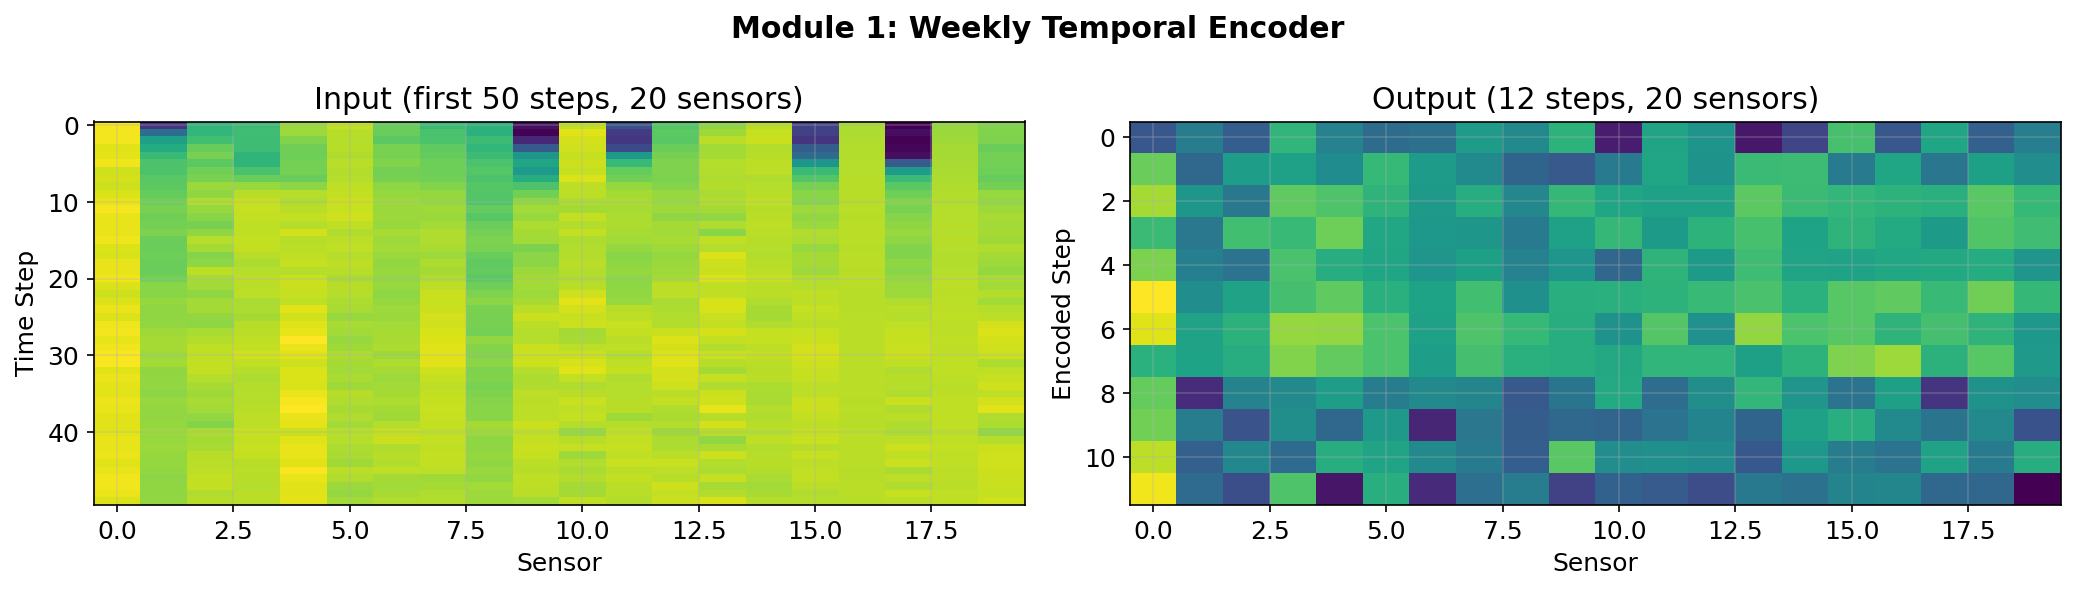

In [7]:
with torch.no_grad():
    Xw_out = model.weekly_enc(Xw)
print(f'Weekly Encoder: {list(Xw.shape)} → {list(Xw_out.shape)}')
print(f'  Compression: {WEEKLY_WINDOW} → {Xw_out.shape[1]} timesteps')
print(f'  Channels: {WEEKLY_IN_CHANNELS} → {WEEKLY_OUT_CHANNELS}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Module 1: Weekly Temporal Encoder', fontweight='bold')
axes[0].imshow(Xw[0,:50,:20,0].cpu().numpy(), aspect='auto', cmap='viridis')
axes[0].set_title(f'Input (first 50 steps, 20 sensors)')
axes[0].set_xlabel('Sensor'); axes[0].set_ylabel('Time Step')
axes[1].imshow(Xw_out[0,:,:20,0].cpu().numpy(), aspect='auto', cmap='viridis')
axes[1].set_title(f'Output ({Xw_out.shape[1]} steps, 20 sensors)')
axes[1].set_xlabel('Sensor'); axes[1].set_ylabel('Encoded Step')
plt.tight_layout(); plt.savefig('/content/arch_weekly_enc.png', dpi=150); plt.show()

Daily Encoder: [8, 288, 325, 3] → [8, 12, 325, 8]
  Compression: 288 → 12 timesteps


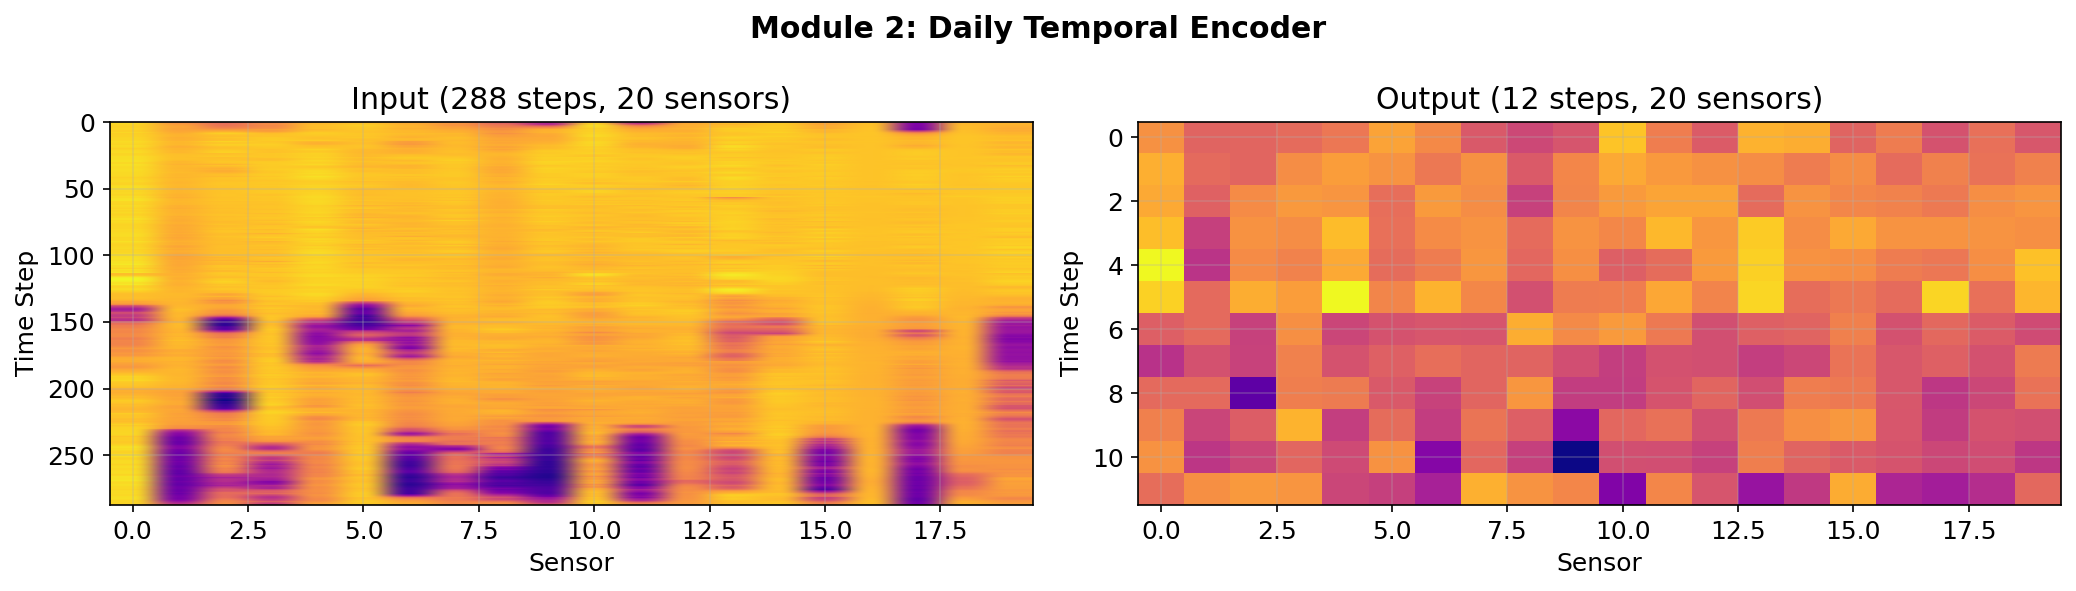

In [8]:
with torch.no_grad():
    Xd_out = model.daily_enc(Xd)
print(f'Daily Encoder: {list(Xd.shape)} → {list(Xd_out.shape)}')
print(f'  Compression: {DAILY_WINDOW} → {Xd_out.shape[1]} timesteps')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Module 2: Daily Temporal Encoder', fontweight='bold')
axes[0].imshow(Xd[0,:,:20,0].cpu().numpy(), aspect='auto', cmap='plasma')
axes[0].set_title(f'Input (288 steps, 20 sensors)')
axes[1].imshow(Xd_out[0,:,:20,0].cpu().numpy(), aspect='auto', cmap='plasma')
axes[1].set_title(f'Output ({Xd_out.shape[1]} steps, 20 sensors)')
for ax in axes: ax.set_xlabel('Sensor'); ax.set_ylabel('Time Step')
plt.tight_layout(); plt.savefig('/content/arch_daily_enc.png', dpi=150); plt.show()

Spatial Embedding: [8, 12, 325, 1] → [8, 12, 325, 16]
  Each sensor: 1 feature → 16 features


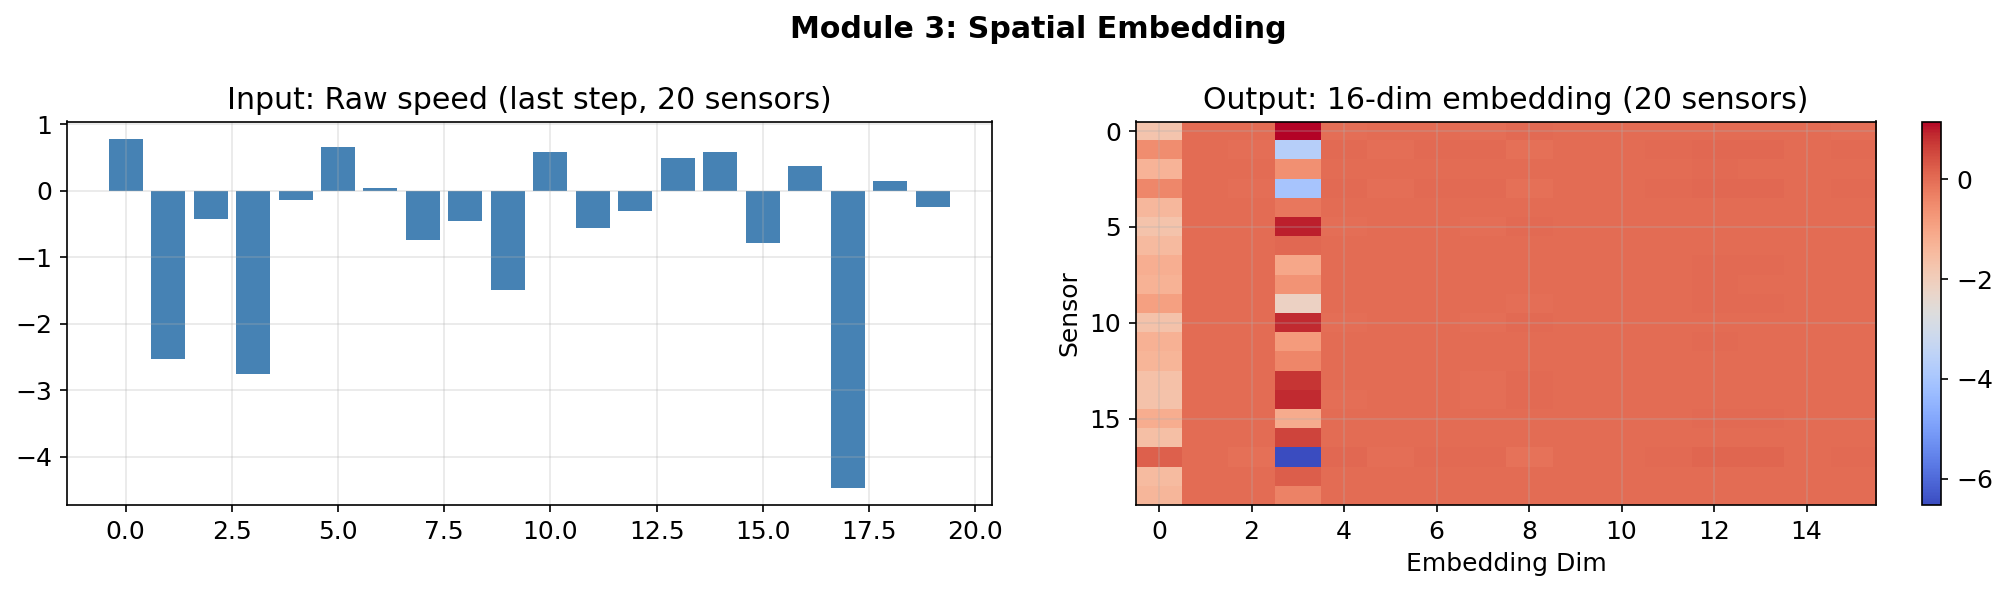

In [9]:
with torch.no_grad():
    Xe = model.sp_embed(Xh)
print(f'Spatial Embedding: {list(Xh.shape)} → {list(Xe.shape)}')
print(f'  Each sensor: 1 feature → {SPATIAL_EMBED_DIM} features')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Module 3: Spatial Embedding', fontweight='bold')
axes[0].bar(range(20), Xh[0,-1,:20,0].cpu().numpy(), color='steelblue')
axes[0].set_title('Input: Raw speed (last step, 20 sensors)')
im = axes[1].imshow(Xe[0,-1,:20,:].cpu().numpy(), aspect='auto', cmap='coolwarm')
axes[1].set_title(f'Output: {SPATIAL_EMBED_DIM}-dim embedding (20 sensors)')
axes[1].set_xlabel('Embedding Dim'); axes[1].set_ylabel('Sensor')
plt.colorbar(im, ax=axes[1]); plt.tight_layout()
plt.savefig('/content/arch_spatial_embed.png', dpi=150); plt.show()

Global Spatial Encoder: [8, 12, 325, 16] → [8, 12, 325, 16]


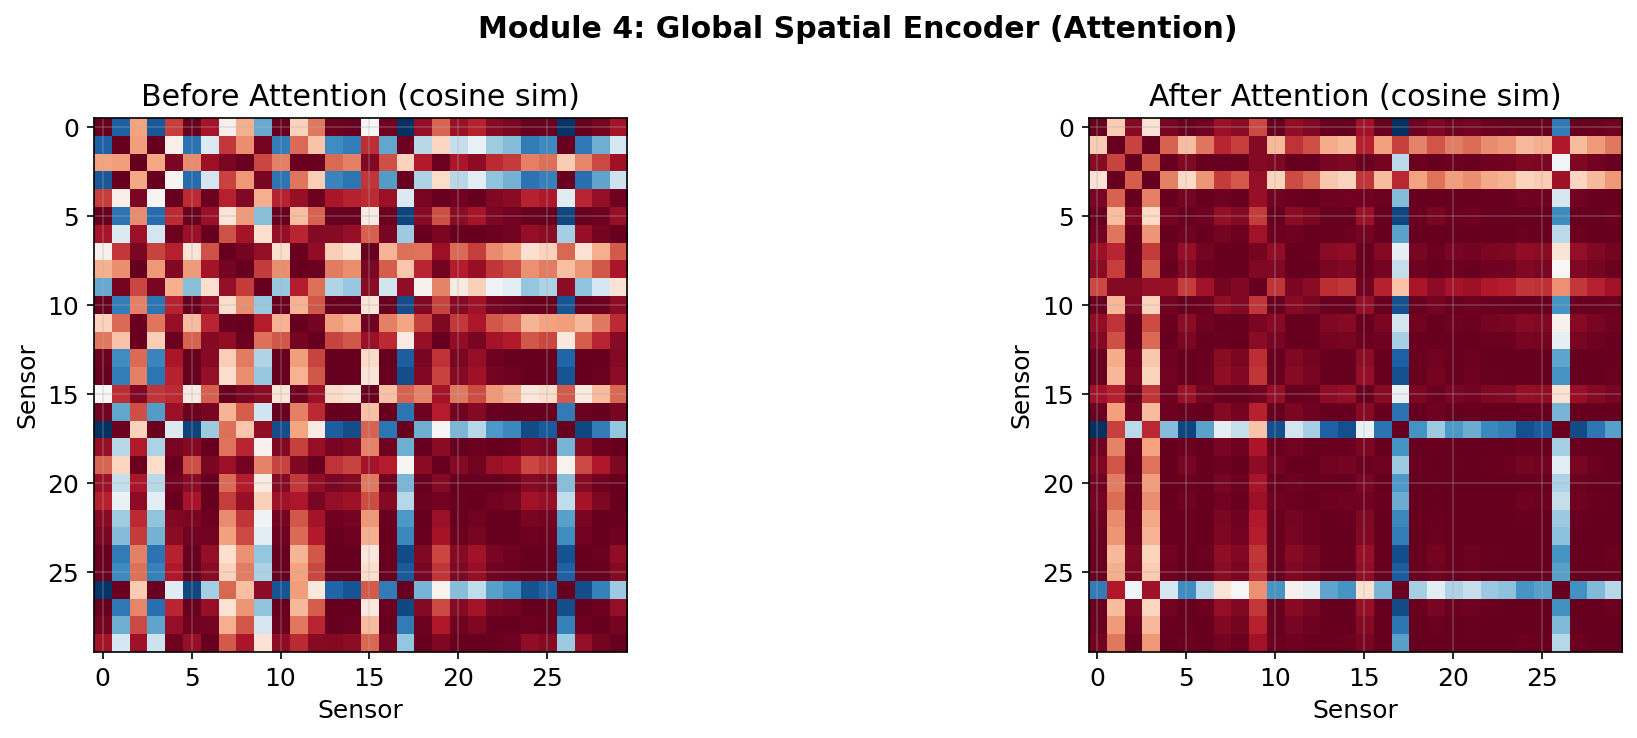

In [10]:
with torch.no_grad():
    Xsa = model.global_enc(Xe)
print(f'Global Spatial Encoder: {list(Xe.shape)} → {list(Xsa.shape)}')

# Visualize attention by comparing input/output similarities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Module 4: Global Spatial Encoder (Attention)', fontweight='bold')
in_sim = torch.cosine_similarity(Xe[0,-1,:30].unsqueeze(1), Xe[0,-1,:30].unsqueeze(0), dim=-1)
out_sim = torch.cosine_similarity(Xsa[0,-1,:30].unsqueeze(1), Xsa[0,-1,:30].unsqueeze(0), dim=-1)
axes[0].imshow(in_sim.cpu().numpy(), cmap='RdBu_r'); axes[0].set_title('Before Attention (cosine sim)')
axes[1].imshow(out_sim.cpu().numpy(), cmap='RdBu_r'); axes[1].set_title('After Attention (cosine sim)')
for ax in axes: ax.set_xlabel('Sensor'); ax.set_ylabel('Sensor')
plt.tight_layout(); plt.savefig('/content/arch_global_enc.png', dpi=150); plt.show()

Local Spatial Encoder: [8, 12, 325, 16] → [8, 12, 325, 8]
  Chebyshev order K=5
  Laplacian shape: [325, 325]


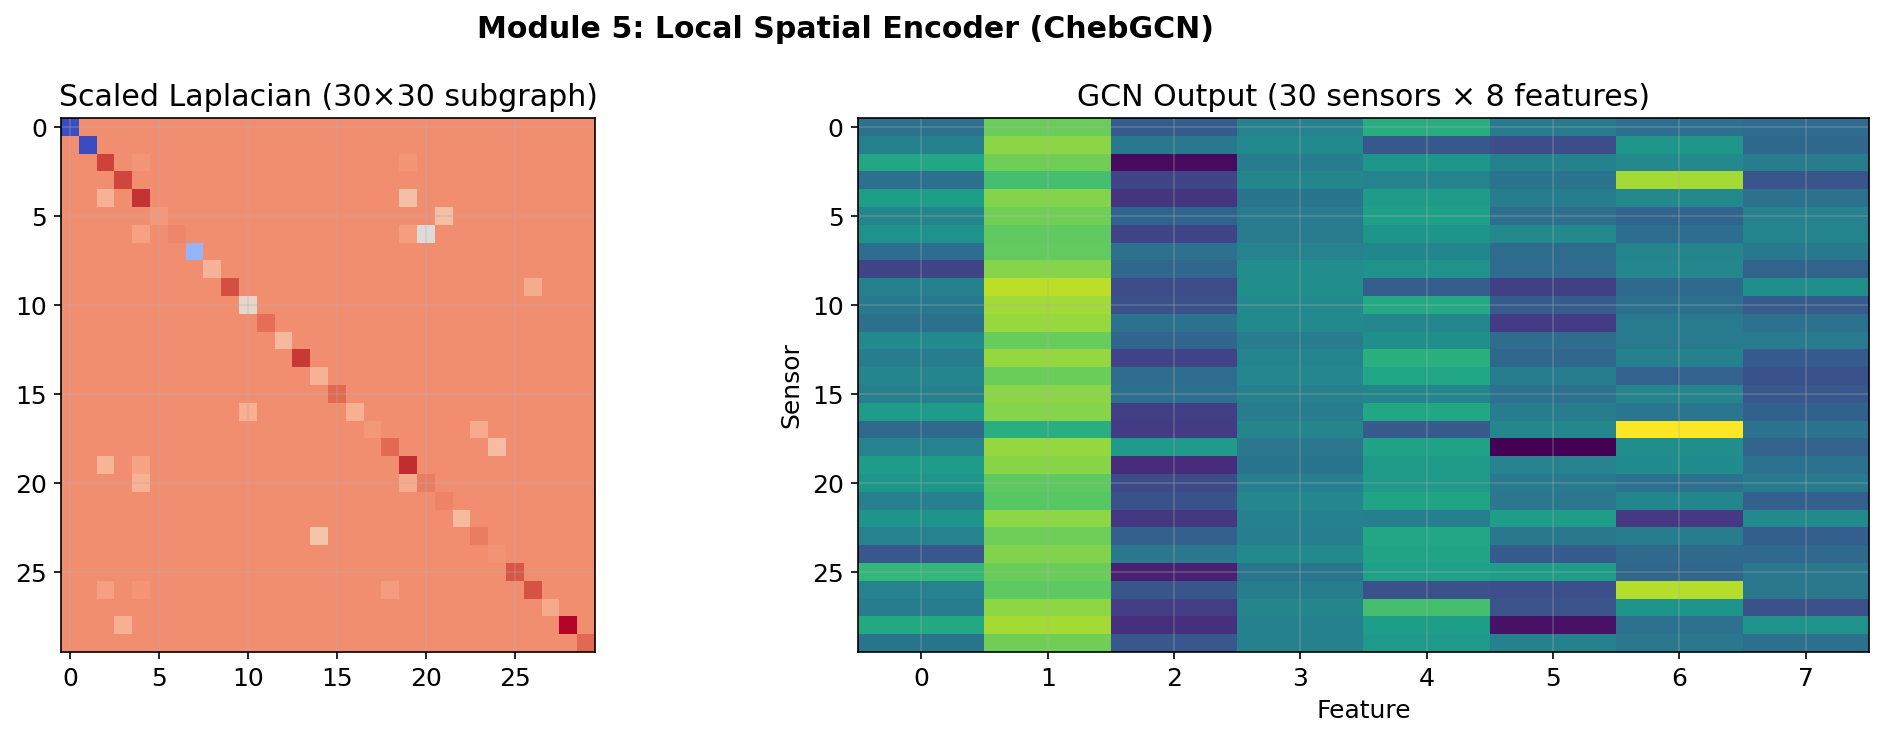

In [11]:
with torch.no_grad():
    Xgcn = model.local_enc(Xe, edge_index, edge_weight)
print(f'Local Spatial Encoder: {list(Xe.shape)} → {list(Xgcn.shape)}')
print(f'  Chebyshev order K={CHEBYSHEV_K}')
print(f'  Laplacian shape: {list(model.local_enc.L_scaled.shape)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Module 5: Local Spatial Encoder (ChebGCN)', fontweight='bold')
axes[0].imshow(model.local_enc.L_scaled[:30,:30].cpu().numpy(), cmap='coolwarm')
axes[0].set_title('Scaled Laplacian (30×30 subgraph)')
axes[1].imshow(Xgcn[0,-1,:30,:].cpu().numpy(), aspect='auto', cmap='viridis')
axes[1].set_title('GCN Output (30 sensors × 8 features)')
axes[1].set_xlabel('Feature'); axes[1].set_ylabel('Sensor')
plt.tight_layout(); plt.savefig('/content/arch_local_enc.png', dpi=150); plt.show()

Fusion: cat([Weekly:16, Daily:8, Global:16, Local:8]) = 48
Time Encoder: [8, 12, 325, 48] → [8, 12, 325, 48]
  Time input: DOW=3, TOD=232 (5-min slot)


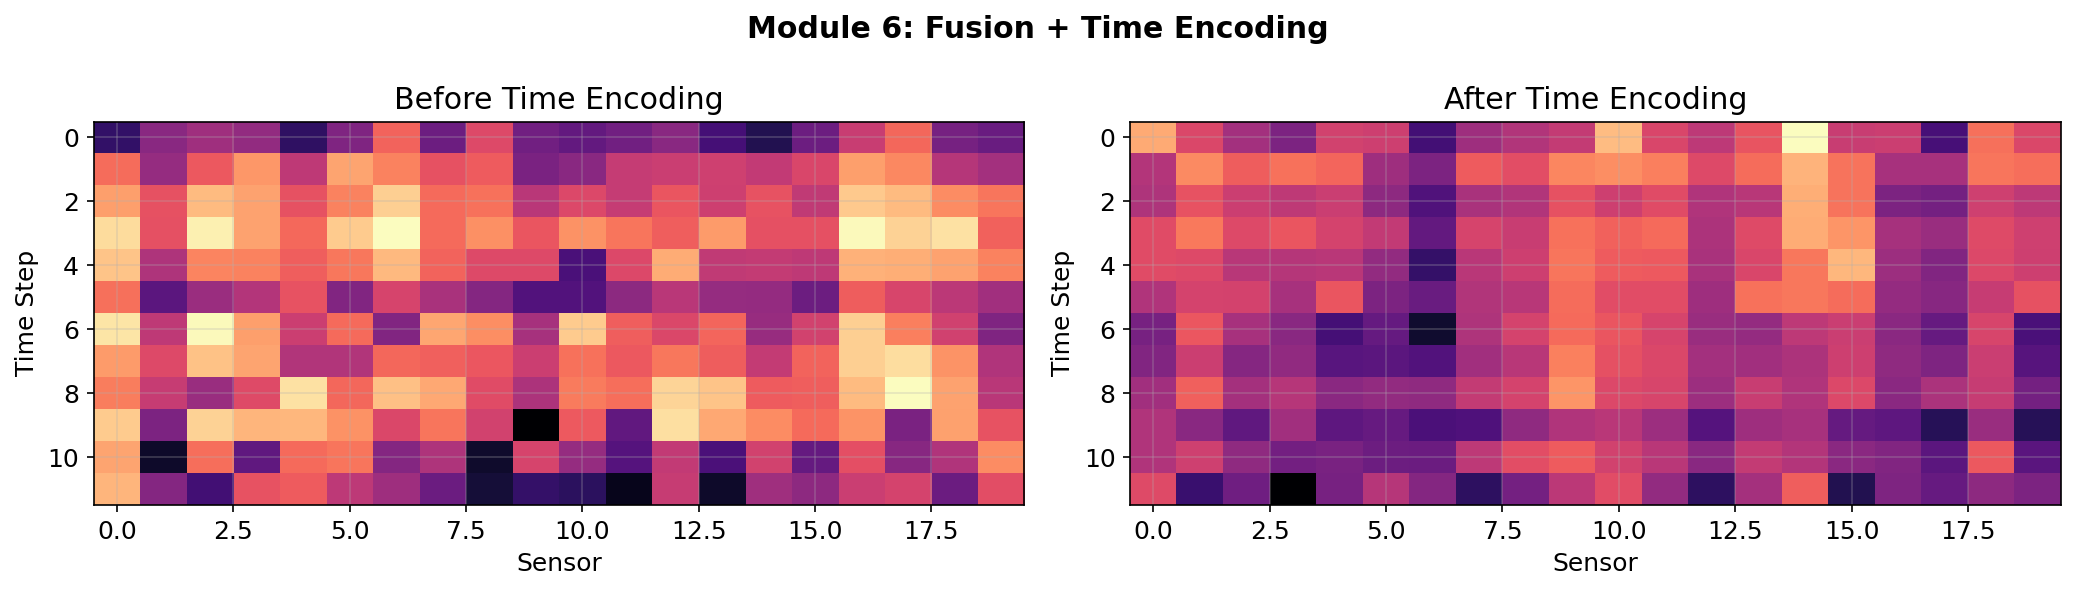

In [12]:
Tt = Xh.shape[1]
Xw_m = model._match_time(Xw_out, Tt)
Xd_m = model._match_time(Xd_out, Tt)
STe = torch.cat([Xw_m, Xd_m, Xsa, Xgcn], dim=-1)
print(f'Fusion: cat([Weekly:{Xw_m.shape[-1]}, Daily:{Xd_m.shape[-1]}, Global:{Xsa.shape[-1]}, Local:{Xgcn.shape[-1]}]) = {STe.shape[-1]}')

with torch.no_grad():
    STE = model.time_enc(STe, ti)
print(f'Time Encoder: {list(STe.shape)} → {list(STE.shape)}')
print(f'  Time input: DOW={ti[0,0].item()}, TOD={ti[0,1].item()} (5-min slot)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Module 6: Fusion + Time Encoding', fontweight='bold')
axes[0].imshow(STe[0,:,:20,:].mean(-1).cpu().numpy(), aspect='auto', cmap='magma')
axes[0].set_title('Before Time Encoding')
axes[1].imshow(STE[0,:,:20,:].mean(-1).cpu().numpy(), aspect='auto', cmap='magma')
axes[1].set_title('After Time Encoding')
for ax in axes: ax.set_xlabel('Sensor'); ax.set_ylabel('Time Step')
plt.tight_layout(); plt.savefig('/content/arch_time_enc.png', dpi=150); plt.show()

Decoder: [8, 12, 325, 48] → [8, 12, 325, 1]
  Forecast horizon: 12 steps (60 minutes)


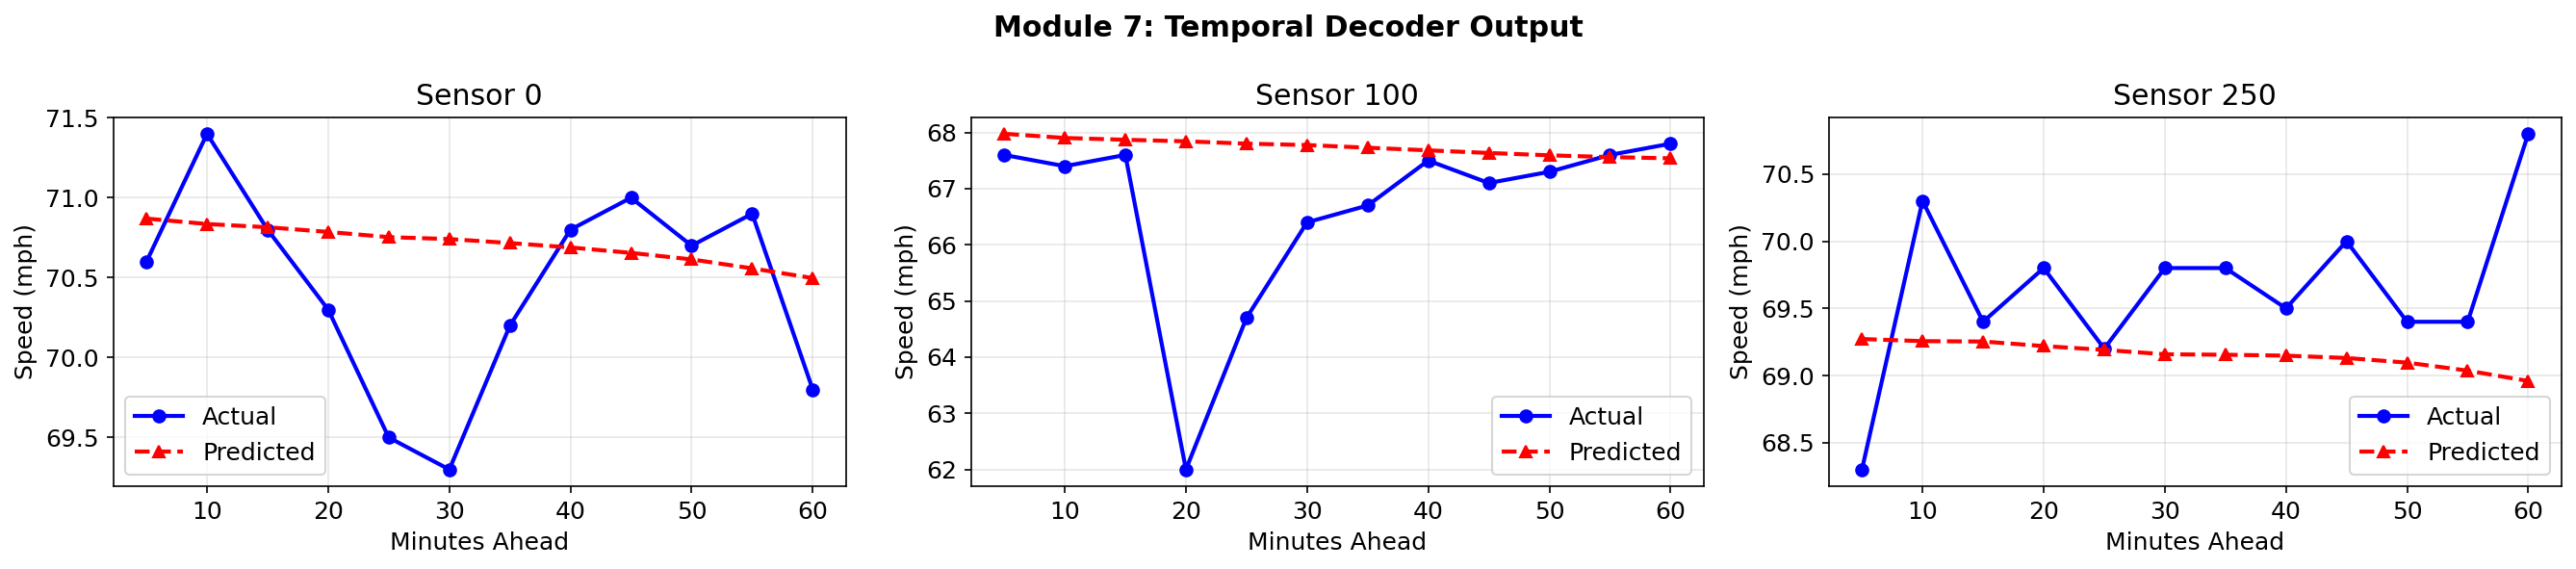

In [13]:
with torch.no_grad():
    pred = model.decoder(STE)
pred_denorm = pred * train_std + train_mean
Y_denorm = Y * train_std + train_mean
print(f'Decoder: {list(STE.shape)} → {list(pred.shape)}')
print(f'  Forecast horizon: {FORECAST_HORIZON} steps ({FORECAST_HORIZON*5} minutes)')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Module 7: Temporal Decoder Output', fontweight='bold')
for ax, s in zip(axes, [0, 100, 250]):
    steps = np.arange(1, FORECAST_HORIZON+1) * 5
    ax.plot(steps, Y_denorm[0,:,s,0].cpu().numpy(), 'bo-', label='Actual', linewidth=2)
    ax.plot(steps, pred_denorm[0,:,s,0].cpu().numpy(), 'r^--', label='Predicted', linewidth=2)
    ax.set_title(f'Sensor {s}'); ax.set_xlabel('Minutes Ahead'); ax.set_ylabel('Speed (mph)')
    ax.legend()
plt.tight_layout(); plt.savefig('/content/arch_decoder.png', dpi=150); plt.show()

In [14]:
summary = [
    ['1. Weekly Temporal Enc', f'(B,2016,N,3)', f'(B,{Xw_out.shape[1]},N,16)', 'Conv1D stride 14→12'],
    ['2. Daily Temporal Enc',  f'(B,288,N,3)',  f'(B,{Xd_out.shape[1]},N,8)',  'Conv1D stride 4→6'],
    ['3. Spatial Embedding',   f'(B,12,N,1)',   f'(B,12,N,16)',  'Conv1D 1→16'],
    ['4. Global Spatial Enc',  f'(B,12,N,16)',  f'(B,12,N,16)',  'MultiHead Attention (4 heads)'],
    ['5. Local Spatial Enc',   f'(B,12,N,16)',  f'(B,12,N,8)',   f'ChebConv K={CHEBYSHEV_K}'],
    ['6. Time Encoder',        f'(B,12,N,48)',  f'(B,12,N,48)',  f'MLP(295→96→48) + LayerNorm'],
    ['7. Temporal Decoder',    f'(B,12,N,48)',  f'(B,12,N,1)',   'Transformer Enc-Dec (6 heads)'],
]
print(f'{"Module":<25} {"Input":>18} {"Output":>18} {"Method"}')
for row in summary:
    print(f'{row[0]:<25} {row[1]:>18} {row[2]:>18} {row[3]}')
n = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {n:,}')

Module                                 Input             Output Method
1. Weekly Temporal Enc          (B,2016,N,3)        (B,12,N,16) Conv1D stride 14→12
2. Daily Temporal Enc            (B,288,N,3)         (B,12,N,8) Conv1D stride 4→6
3. Spatial Embedding              (B,12,N,1)        (B,12,N,16) Conv1D 1→16
4. Global Spatial Enc            (B,12,N,16)        (B,12,N,16) MultiHead Attention (4 heads)
5. Local Spatial Enc             (B,12,N,16)         (B,12,N,8) ChebConv K=5
6. Time Encoder                  (B,12,N,48)        (B,12,N,48) MLP(295→96→48) + LayerNorm
7. Temporal Decoder              (B,12,N,48)         (B,12,N,1) Transformer Enc-Dec (6 heads)

Total trainable parameters: 109,428
